In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [2]:
df=pd.read_csv("online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
 8   TotalAmount  397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.4+ MB


In [10]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

In [11]:
# Missing CustomerID remove
df = df.dropna(subset=['CustomerID'])

# Negative Quantity remove (ya alag se returns banao)
df = df[df['Quantity'] > 0]

# UnitPrice > 0
df = df[df['UnitPrice'] > 0]

# Datetime convert
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Total Amount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

In [12]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [13]:
df.shape

(397884, 9)

In [14]:
# Final Cleaning
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df['CustomerID'].astype(int)

# Check again
print(df.shape)
print(df.isnull().sum())
df.head()

(397884, 9)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [15]:

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

df['Description'] = df['Description'].str.strip()

In [16]:
print("Total Orders:", df['InvoiceNo'].nunique())
print("Total Customers:", df['CustomerID'].nunique())
print("Total Products:", df['StockCode'].nunique())
print("Total Revenue: £", round(df['TotalAmount'].sum(), 2))
print("Average Order Value: £", round(df.groupby('InvoiceNo')['TotalAmount'].sum().mean(), 2))

Total Orders: 18532
Total Customers: 4338
Total Products: 3665
Total Revenue: £ 8911407.9
Average Order Value: £ 480.87


In [17]:
# Reference date (data ka last date)
latest_date = df['InvoiceDate'].max()
print("Latest Date:", latest_date)

# RFM Table banana
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalAmount': 'sum'                                     # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Check
print(rfm.head(10))
print("\nShape:", rfm.shape)
rfm.describe()

Latest Date: 2011-12-09 12:50:00
   CustomerID  Recency  Frequency  Monetary
0       12346      325          1  77183.60
1       12347        1          7   4310.00
2       12348       74          4   1797.24
3       12349       18          1   1757.55
4       12350      309          1    334.40
5       12352       35          8   2506.04
6       12353      203          1     89.00
7       12354      231          1   1079.40
8       12355      213          1    459.40
9       12356       22          3   2811.43

Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,91.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,0.000000,1.000000,3.750000
25%,13813.250000,17.000000,1.000000,307.415000
50%,15299.500000,50.000000,2.000000,674.485000
75%,16778.750000,141.000000,5.000000,1661.740000
max,18287.000000,373.000000,209.000000,280206.020000


In [18]:
# RFM Scoring (1 to 5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])          # Kam Recency = Better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Scores make integer
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# RFM Score combine
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Customer Segments
def segment_customer(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'Promising'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2 and row['M_Score'] <= 2:
        return 'Need Attention'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2 and row['M_Score'] >= 3:
        return 'Cant Lose'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Result
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'Segment']].head(15))
print("\nSegment Distribution:")
print(rfm['Segment'].value_counts())

    CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0        12346      325          1  77183.60        1        1        5   
1        12347        1          7   4310.00        5        5        5   
2        12348       74          4   1797.24        2        4        4   
3        12349       18          1   1757.55        4        1        4   
4        12350      309          1    334.40        1        1        2   
5        12352       35          8   2506.04        3        5        5   
6        12353      203          1     89.00        1        1        1   
7        12354      231          1   1079.40        1        1        4   
8        12355      213          1    459.40        1        1        2   
9        12356       22          3   2811.43        4        3        5   
10       12357       32          1   6207.67        4        1        5   
11       12358        1          2   1168.06        5        2        4   
12       12359       57  

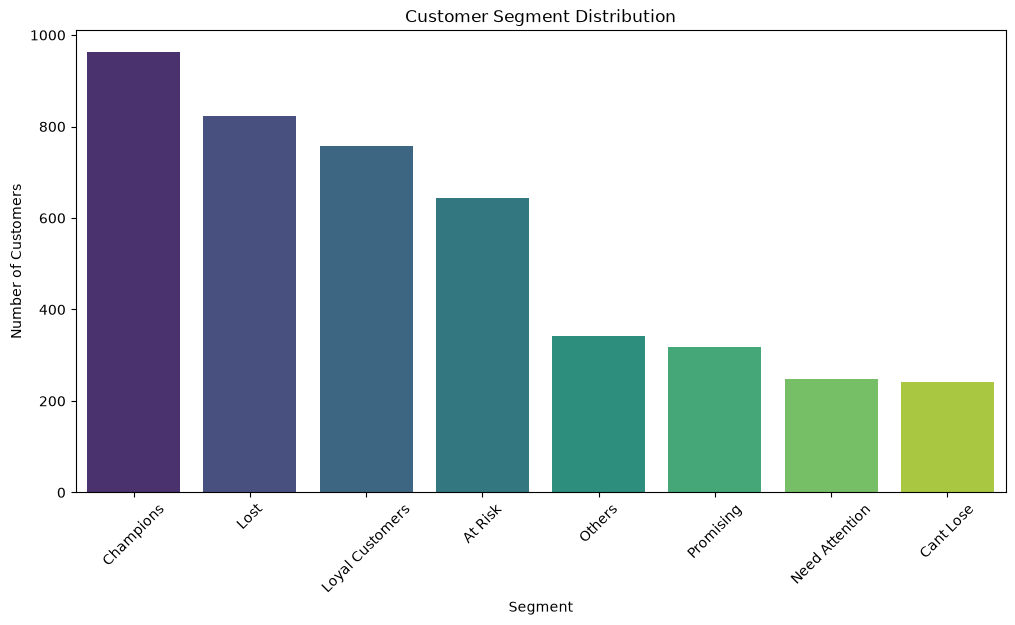

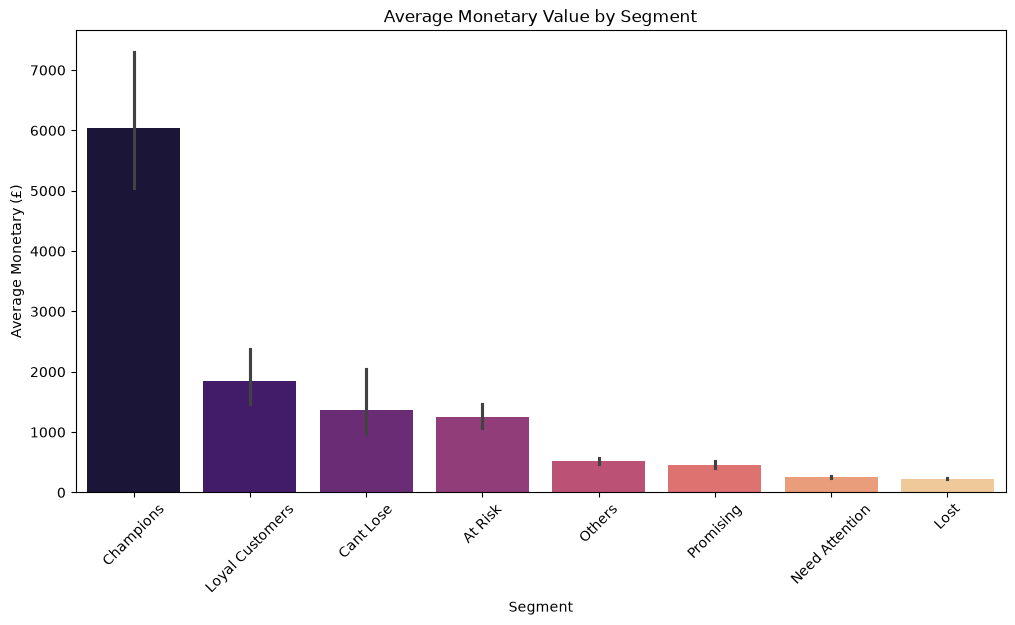

In [21]:
# Segment Distribution Chart
plt.figure(figsize=(12,6))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Customer Segment Distribution')
plt.xticks(rotation=45)
plt.ylabel('Number of Customers')
plt.show()

# Average Monetary by Segment
plt.figure(figsize=(12,6))
sns.barplot(data=rfm, x='Segment', y='Monetary', order=rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False).index, palette='magma')
plt.title('Average Monetary Value by Segment')
plt.xticks(rotation=45)
plt.ylabel('Average Monetary (£)')
plt.show()

### Key Insights

- **Champions (962 customers)**: Highest value customers. Yeh log frequently buy karte hain aur recently bhi active hain.
- **Loyal Customers (758)**: Regular buyers. Inhe retain karna bahut zaroori hai.
- **At Risk (643) + Cant Lose (241)**: Pehle achhe customers the, ab kam active ho gaye hain. Inpe focus karna chahiye.
- **Lost (824)**: Bahut saare customers kho chuke hain. Yeh serious concern hai.
- **Promising (319)**: Naye customers jo recently aaye hain, unhe loyal banane ka opportunity hai.

### Business Recommendations

1. Champions & Loyal Customers pe exclusive offers, early access aur loyalty rewards do.
2. At Risk & Cant Lose customers ko personalized win-back campaigns (discount + reminder) bhejo.
3. Promising customers ko onboarding offers do taaki woh Loyal bane.
4. Lost customers ke liye re-activation campaign try karo (budget limited rakho).
5. Overall focus: Customer retention badhao, kyunki naye customers lana mehnga padta hai.

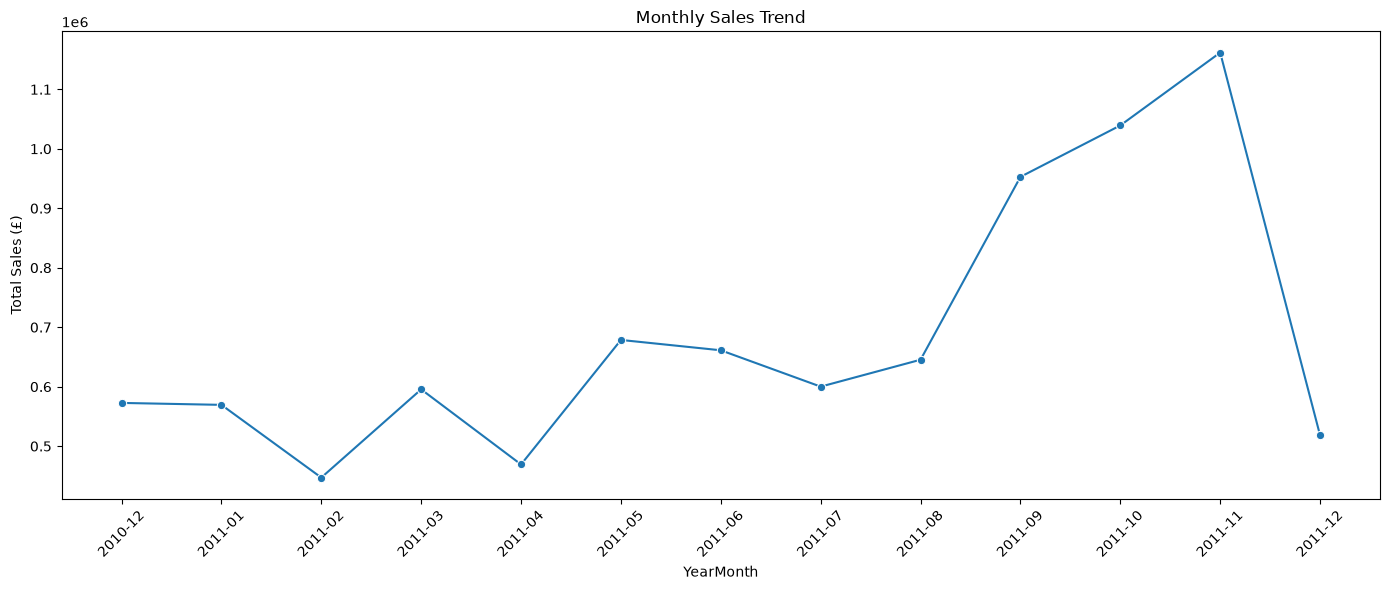

In [22]:
# Create YearMonth column
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Monthly Sales
monthly_sales = df.groupby('YearMonth')['TotalAmount'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

# Plot
plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='TotalAmount', marker='o')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.ylabel('Total Sales (£)')
plt.tight_layout()
plt.show()

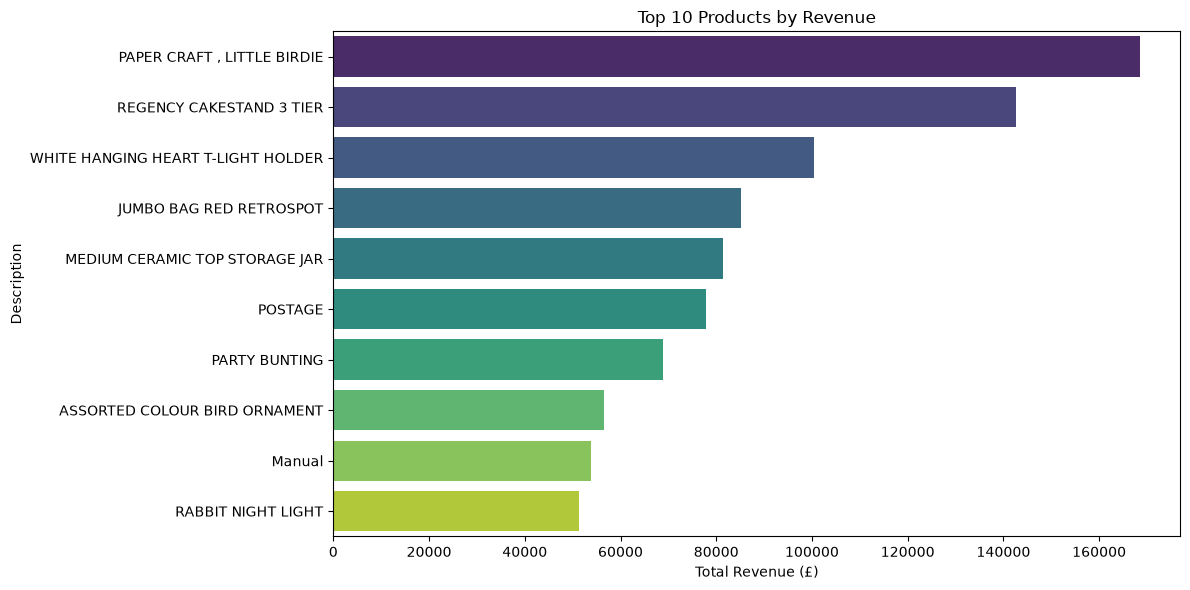

In [23]:
top_products = df.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

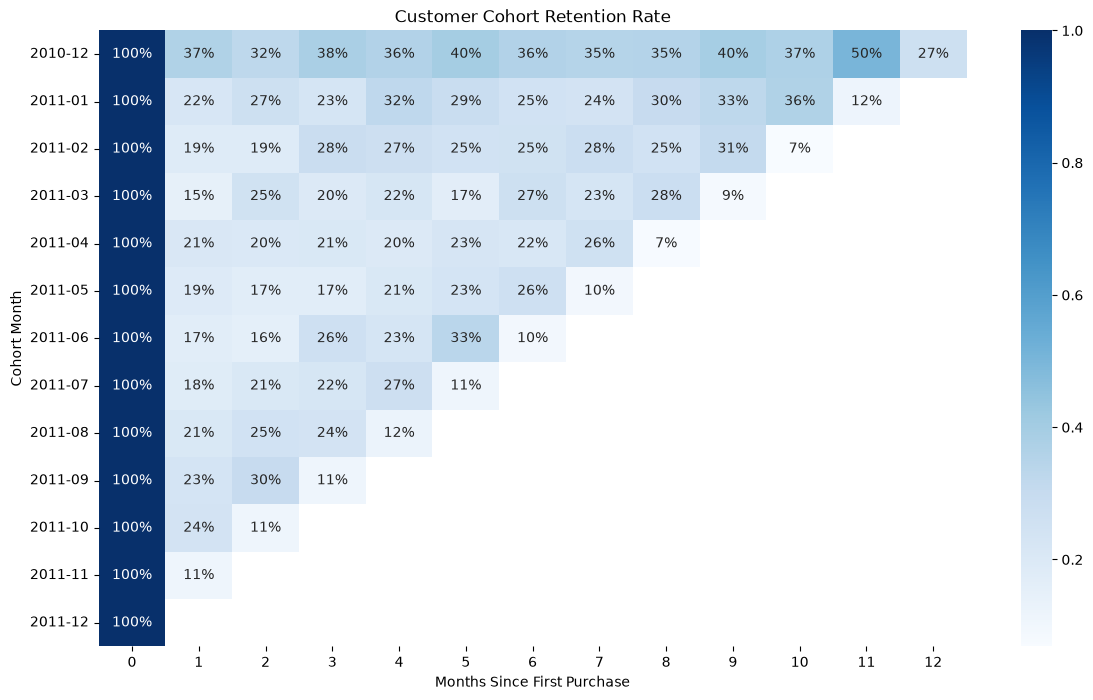

In [24]:
# Create Cohort Month (First purchase month of customer)
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# Create Order Month
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')

# Calculate Cohort Index (months since first purchase)
df['CohortIndex'] = (df['OrderMonth'] - df['CohortMonth']).apply(lambda x: x.n)

# Cohort table
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# Retention Rate
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='Blues')
plt.title('Customer Cohort Retention Rate')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()

### Project Summary

**Dataset:** Online Retail (UCI)  
**Period:** Dec 2010 – Dec 2011  
**Total Customers:** 4,338  
**Total Orders:** 18,532  
**Total Revenue:** £ 8.91 Million

### Key Analysis Done
- Data Cleaning & Preprocessing
- RFM Analysis + Customer Segmentation
- Monthly Sales Trend
- Top Products by Revenue
- Cohort Analysis (Customer Retention)

### Major Insights
- Champions + Loyal Customers contribute significantly to revenue
- High number of Lost & At Risk customers → Retention opportunity
- Strong seasonal patterns in sales
- Clear difference in customer behavior across segments

In [25]:
# Clean transaction data
df_export = df[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 
                'UnitPrice', 'CustomerID', 'Country', 'TotalAmount']].copy()

df_export.to_csv('transactions.csv', index=False)
print("transactions.csv saved")

transactions.csv saved


In [26]:
rfm_export = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 
                  'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']].copy()

rfm_export.to_csv('rfm_segments.csv', index=False)
print("rfm_segments.csv saved")

rfm_segments.csv saved


In [27]:
monthly_sales.to_csv('monthly_sales.csv', index=False)
print("monthly_sales.csv saved")

monthly_sales.csv saved
